# Diabetes Risk Classification Using CatBoost

This standalone notebook contains the same shared preprocessing pipeline from the original workflow, followed by the CatBoost model only.

The workflow includes:

1. Exploratory Data Analysis (EDA)
2. Feature engineering and preprocessing
3. Feature selection and scaling
4. CatBoost experiments, model comparison, and XAI using feature importance, SHAP, and LIME
5. Model evaluation using accuracy, classification report, and imbalance-aware interpretation

## 1. Imports

All required libraries are loaded here. The notebook uses classical machine learning models, CatBoost, neural networks, imbalance-handling methods, and explainability tools.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

## 2. Exploratory Data Analysis

This section checks the dataset structure, missing values, descriptive statistics, class imbalance, correlations, outliers, and important feature distributions. The EDA confirms that the task is imbalanced, which strongly affects model evaluation and makes accuracy alone unreliable.

In [2]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [5]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [6]:
df['Diabetes_012'].value_counts(normalize=True)

,proportion
Diabetes_012,
0.0,0.842412
2.0,0.139333
1.0,0.018255


In [7]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['BMI'] < Q1 - 1.5*IQR) | (df['BMI'] > Q3 + 1.5*IQR)]
print("Number of BMI outliers:", len(outliers))

Number of BMI outliers: 9847


In [8]:
df.groupby('Diabetes_012')[['BMI','Age','PhysHlth','MentHlth']].mean()

,BMI,Age,PhysHlth,MentHlth
Diabetes_012,,,,
0.0,27.742521,7.786559,3.582416,2.944404
1.0,30.724466,9.083351,6.348305,4.529907
2.0,31.944011,9.379053,7.954479,4.461806


In [9]:
corr = df.corr()['Diabetes_012'].sort_values(ascending=False)
print(corr)

Diabetes_012            1.000000
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64


In [10]:
df[['BMI','Age','PhysHlth','MentHlth']].skew()

,0
BMI,2.122004
Age,-0.359903
PhysHlth,2.207395
MentHlth,2.721148


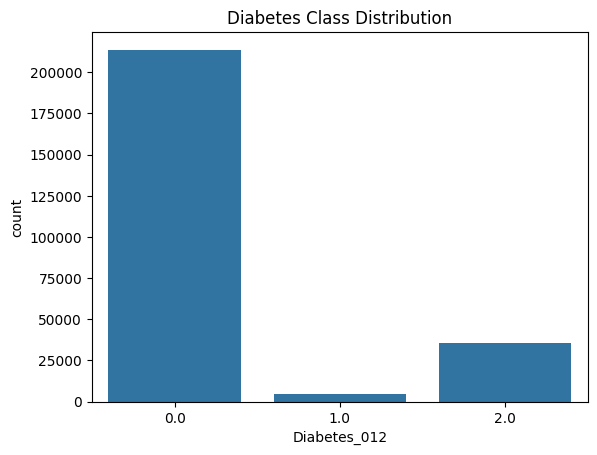

In [11]:
sns.countplot(x='Diabetes_012', data=df)
plt.title("Diabetes Class Distribution")
plt.show()

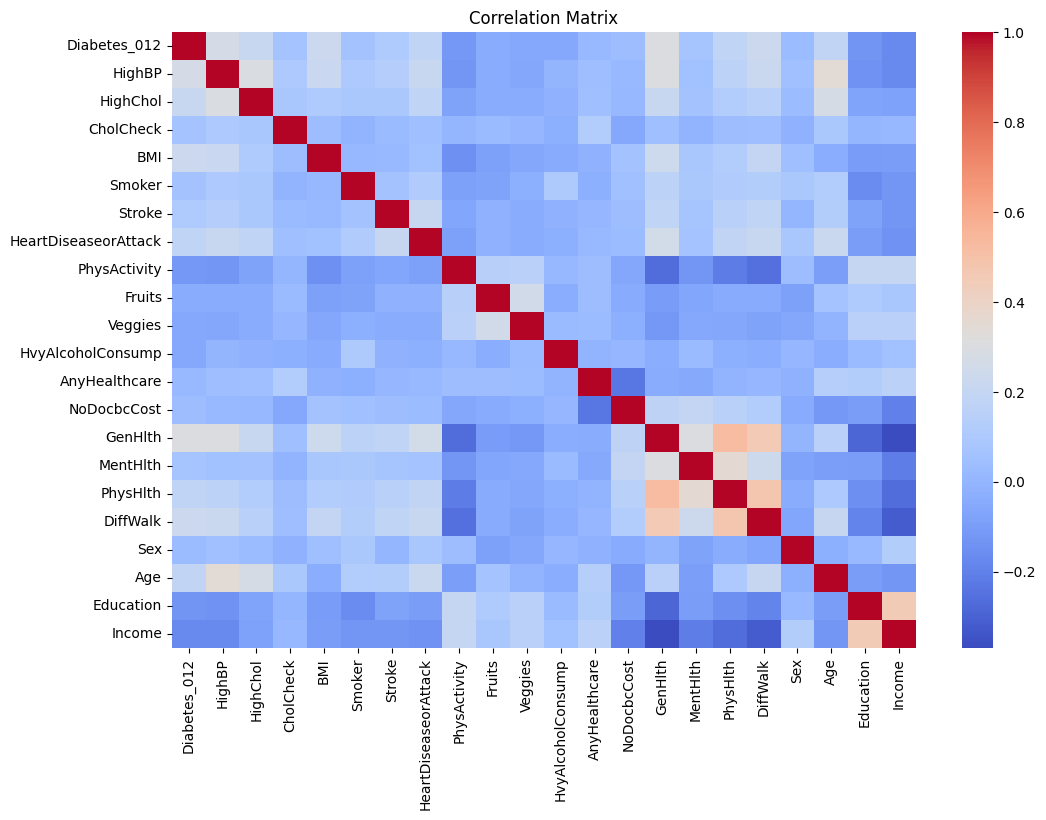

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

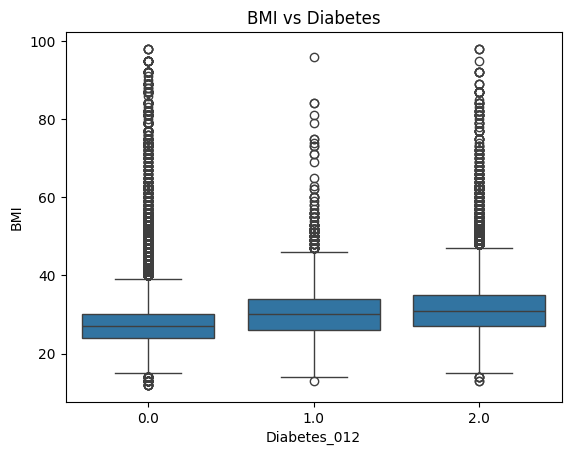

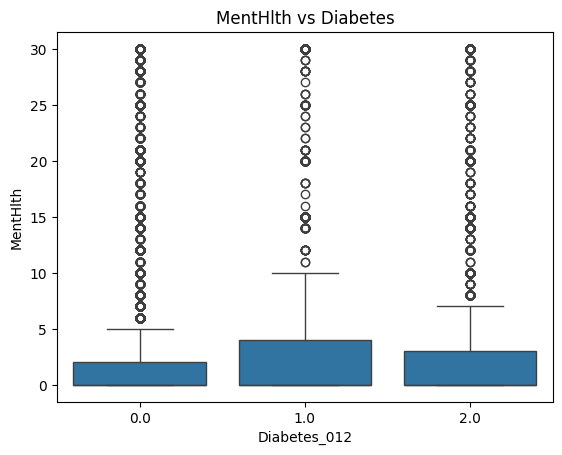

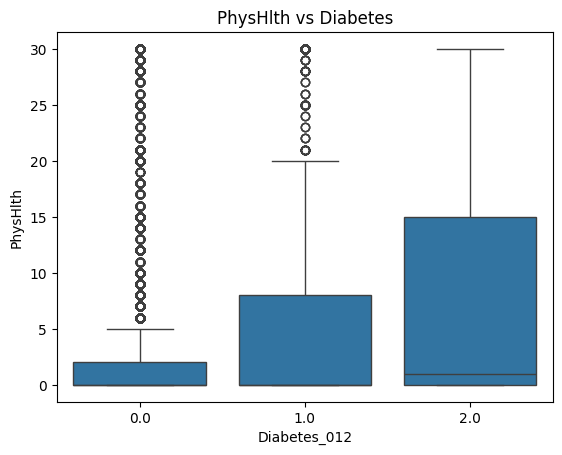

In [13]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth']

for col in continuous_cols:
    plt.figure()
    sns.boxplot(x='Diabetes_012', y=col, data=df)
    plt.title(f'{col} vs Diabetes')
    plt.show()

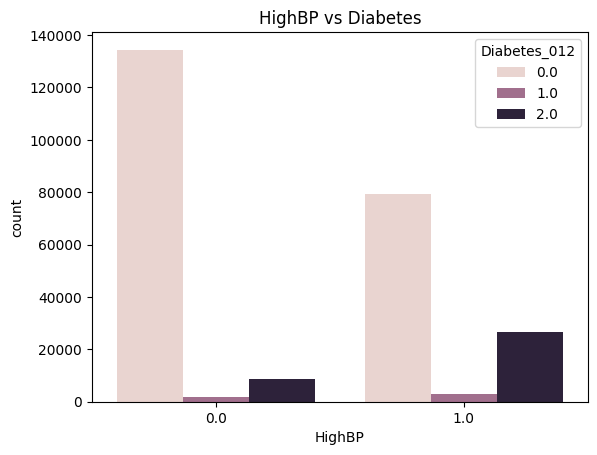

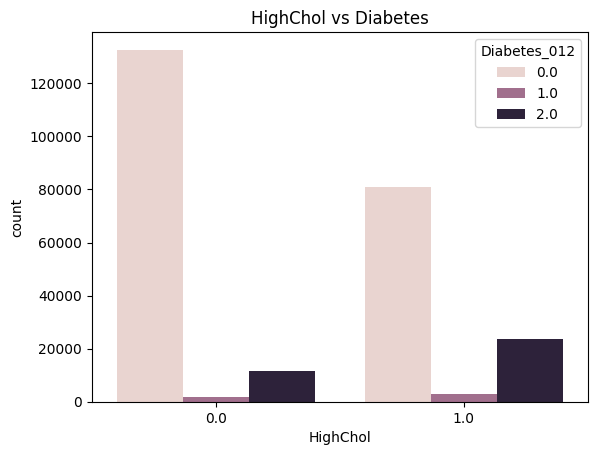

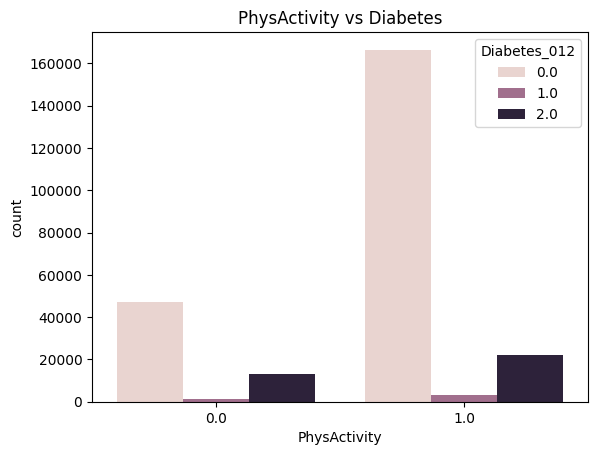

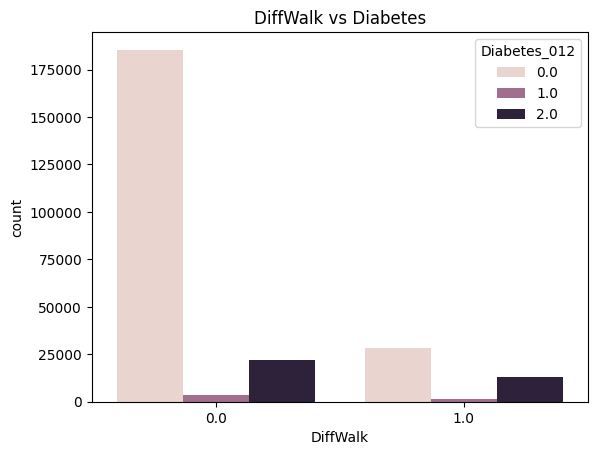

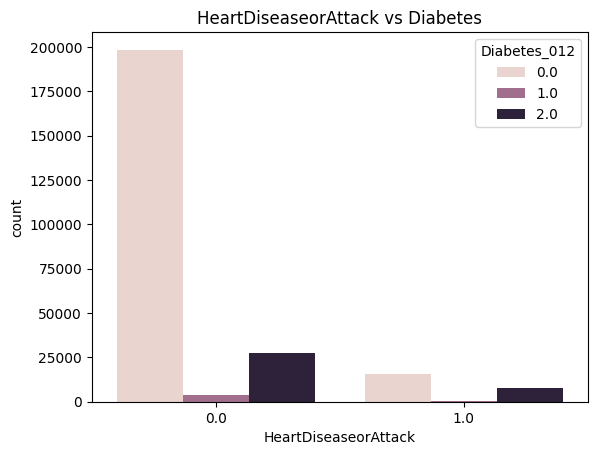

In [14]:
cat_cols = ['HighBP','HighChol','PhysActivity','DiffWalk','HeartDiseaseorAttack']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='Diabetes_012', data=df)
    plt.title(f'{col} vs Diabetes')
    plt.show()

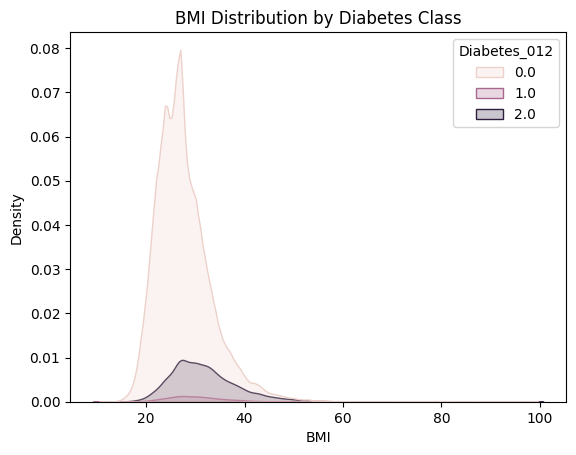

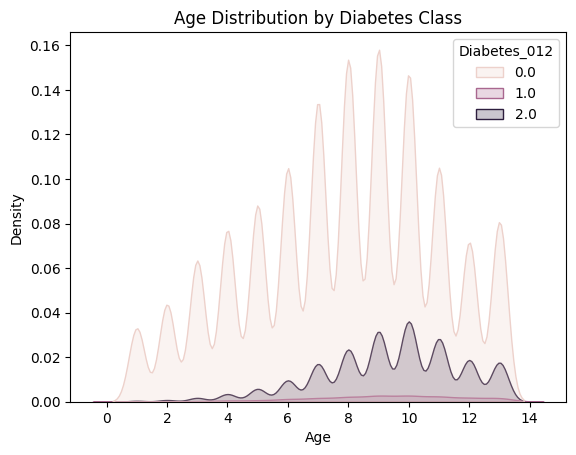

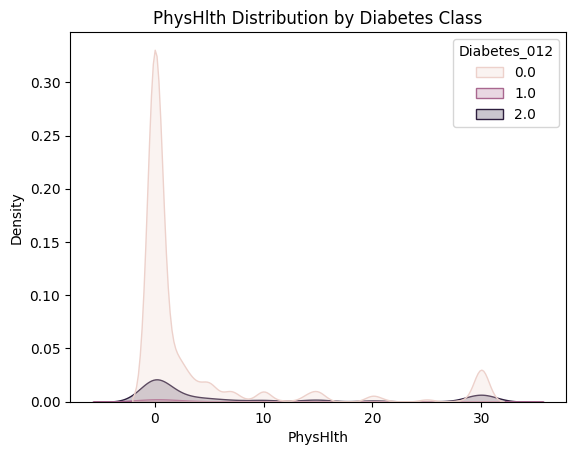

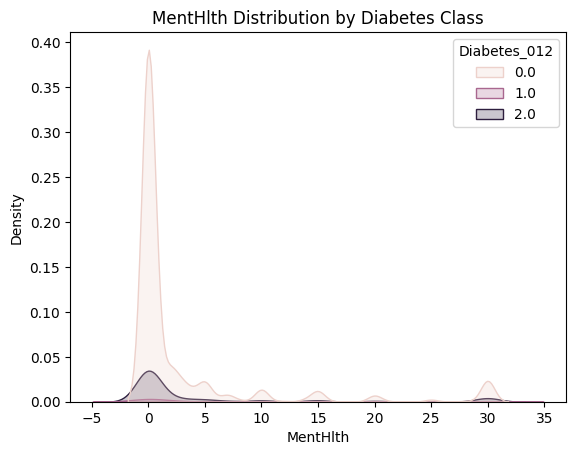

In [15]:
for col in ['BMI','Age','PhysHlth','MentHlth']:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Diabetes_012', fill=True)
    plt.title(f'{col} Distribution by Diabetes Class')
    plt.show()

## 3. Feature Engineering and Data Cleaning

The preprocessing stage removes duplicate rows, handles BMI outliers using the IQR rule, creates an interaction feature between BMI and age, and removes selected low-value or less useful columns. The target variable remains `Diabetes_012` with three classes.

In [16]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 23899
Duplicates after: 0


In [17]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['BMI'] >= lower) & (df['BMI'] <= upper)]

remaining_outliers = df[(df['BMI'] < lower) | (df['BMI'] > upper)]

print("Remaining outliers:", len(remaining_outliers))

Remaining outliers: 0


In [18]:
df['BMI_Age'] = df['BMI'] * df['Age']

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

drop_cols = ['AnyHealthcare', 'CholCheck', 'Sex']
X = X.drop(columns=drop_cols)

## 4. Feature Selection, Train/Test Split, and Scaling

Correlation-based feature selection is applied to keep features that have a measurable relationship with the target. The data is then split using stratification to preserve the original class distribution. Robust scaling is used because some health-related numeric features contain skewness and outliers.

In [19]:
corr = df.corr()['Diabetes_012'].abs().sort_values(ascending=False)

selected_features = corr[corr > 0.05].index.drop('Diabetes_012')

selected_features = [col for col in selected_features if col in X.columns]

print("Selected Features:", list(selected_features))

X = X[selected_features]

Selected Features: ['BMI_Age', 'GenHlth', 'HighBP', 'BMI', 'HighChol', 'DiffWalk', 'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'Income', 'Education', 'Stroke', 'PhysActivity', 'HvyAlcoholConsump']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler = RobustScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features)
X_test = pd.DataFrame(scaler.transform(X_test), columns=selected_features)


# scaler = StandardScaler()

# X_train_res = scaler.fit_transform(X_train_res)
# X_test = scaler.transform(X_test)

## 5. Modeling Strategy

Because this is an imbalanced three-class classification problem, every model is judged using more than accuracy. The key evaluation signals are:

- **Accuracy:** overall correctness, but can be misleading when Class 0 dominates.
- **Macro F1:** treats all classes equally, so it is useful for imbalance.
- **Class 1 and Class 2 recall:** shows whether the model detects minority diabetes-related classes.
- **Confusion matrix:** shows where the model is biased or confused.

The notebook keeps the results of all tested models, including models that are not selected as final models, to make the comparison transparent.

# Phase 2: CatBoost Model Experiments

CatBoost is tested because gradient boosting models usually perform strongly on tabular datasets. Several imbalance-handling strategies are compared. Not every CatBoost experiment is selected as final, but all results are kept visible for a fair comparison.

## 1. Install and Import CatBoost Libraries

- Installs CatBoost and imbalance-handling libraries if needed.
- Imports metrics used for evaluation.
- Imports plotting libraries for the confusion matrix and explainability graphs.


In [22]:
!pip install catboost imbalanced-learn lime shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


## 2. Check Class Distribution

- This cell shows the distribution of the target classes in the training and testing data.
- The dataset is imbalanced because Class 0 has many more samples than Class 1 and Class 2.
- This imbalance explains why accuracy alone can be misleading.


In [23]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
Diabetes_012
0.0    147095
1.0      3470
2.0     25384
Name: count, dtype: int64

Testing class distribution:
Diabetes_012
0.0    36774
1.0      868
2.0     6346
Name: count, dtype: int64


## 3. Evaluation Helper Function

- This function evaluates each CatBoost experiment in the same format.
- It reports accuracy, macro F1, weighted F1, Class 1 recall, and Class 2 recall.
- Macro F1 and minority-class recall are important because this is an imbalanced medical dataset.


In [24]:
def evaluate_catboost_model(model_name, y_true, y_pred):
    y_pred = np.asarray(y_pred).flatten()

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    class_1_recall = report_dict.get("1.0", report_dict.get("1", {})).get("recall", 0)
    class_2_recall = report_dict.get("2.0", report_dict.get("2", {})).get("recall", 0)

    print(model_name)
    print("-" * len(model_name))
    print("Accuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print("Class 1 Recall:", class_1_recall)
    print("Class 2 Recall:", class_2_recall)
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Class 1 Recall": class_1_recall,
        "Class 2 Recall": class_2_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }

catboost_results = []


## 4. Experiment 1: CatBoost Without SMOTE

- This model is trained on the original imbalanced training data.
- No SMOTE and no class weights are used.
- This experiment acts as the basic CatBoost baseline.
- It usually gives high accuracy because it learns the majority class very well.


In [25]:
# Experiment only — not selected as final CatBoost because it is strongly biased toward Class 0 and gives very weak minority-class recall.

catboost_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

catboost_baseline.fit(X_train, y_train)

y_pred_baseline = catboost_baseline.predict(X_test).flatten()

baseline_result = evaluate_catboost_model(
    "CatBoost Without SMOTE",
    y_test,
    y_pred_baseline
)

catboost_results.append(baseline_result)


CatBoost Without SMOTE
----------------------
Accuracy: 0.8407065563335455
Macro F1: 0.38127449342024144
Weighted F1: 0.7959668137715025
Class 1 Recall: 0.0
Class 2 Recall: 0.14733690513709424

Classification Report:

              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91     36774
         1.0       0.00      0.00      0.00       868
         2.0       0.54      0.15      0.23      6346

    accuracy                           0.84     43988
   macro avg       0.46      0.38      0.38     43988
weighted avg       0.79      0.84      0.80     43988



### Result Explanation: CatBoost Without SMOTE

- This model may achieve the **highest accuracy** because most samples are Class 0.
- However, if Class 1 recall and Class 2 recall are low, the model is biased toward the majority class.
- For diabetes risk prediction, this is not enough because the model should detect patients at risk, not only healthy cases.


## 5. Experiment 2: CatBoost With SMOTE

- SMOTE is applied only on the training data.
- The test data is not changed because it must represent real unseen data.
- This experiment tests whether synthetic minority-class samples help CatBoost detect Class 1 and Class 2 better.


In [26]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())


Before SMOTE:
Diabetes_012
0.0    147095
1.0      3470
2.0     25384
Name: count, dtype: int64

After SMOTE:
Diabetes_012
0.0    147095
1.0    147095
2.0    147095
Name: count, dtype: int64


## 6. Train CatBoost With SMOTE

- This model uses the same CatBoost baseline settings.
- The only difference is that it trains on `X_train_smote` and `y_train_smote`.
- The result is compared with the baseline model to see the effect of balancing.


In [27]:
# Experiment only — not selected as final CatBoost because SMOTE improves Class 2 recall but Class 1 recall remains zero.

catboost_smote = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

catboost_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = catboost_smote.predict(X_test).flatten()

smote_result = evaluate_catboost_model(
    "CatBoost With SMOTE",
    y_test,
    y_pred_smote
)

catboost_results.append(smote_result)


CatBoost With SMOTE
-------------------
Accuracy: 0.8307720287351096
Macro F1: 0.42615266340285846
Weighted F1: 0.8102188367173822
Class 1 Recall: 0.0
Class 2 Recall: 0.3170501103057044

Classification Report:

              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90     36774
         1.0       0.00      0.00      0.00       868
         2.0       0.46      0.32      0.37      6346

    accuracy                           0.83     43988
   macro avg       0.44      0.42      0.43     43988
weighted avg       0.80      0.83      0.81     43988



### Result Explanation: CatBoost With SMOTE

- SMOTE usually reduces the majority-class bias.
- If accuracy decreases slightly but Class 2 recall improves, this is still a useful improvement.
- In this project, diabetes detection is more important than only maximizing total accuracy.
- If Class 1 is still weak, this means prediabetes is difficult to separate from the other classes.


## 7. Experiment 3: CatBoost With Borderline-SMOTE and Class Weights

- Borderline-SMOTE generates synthetic samples close to the class boundary.
- Class weights are also used to increase the penalty for minority-class mistakes.
- This experiment checks whether a stronger imbalance strategy improves diabetes detection even more.


In [28]:
# Experiment only — not selected as final CatBoost because it increases Class 2 recall but reduces overall stability and weighted performance.

borderline_smote = BorderlineSMOTE(
    sampling_strategy={
        1: 10000,
        2: 35000
    },
    random_state=42
)

X_train_border, y_train_border = borderline_smote.fit_resample(X_train, y_train)

print("Before Borderline-SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nAfter Borderline-SMOTE:")
print(pd.Series(y_train_border).value_counts().sort_index())

catboost_border = CatBoostClassifier(
    iterations=700,
    learning_rate=0.03,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=[1, 6, 3],
    random_seed=42,
    verbose=0
)

catboost_border.fit(X_train_border, y_train_border)

y_pred_border = catboost_border.predict(X_test).flatten()

border_result = evaluate_catboost_model(
    "CatBoost With Borderline-SMOTE and Class Weights",
    y_test,
    y_pred_border
)

catboost_results.append(border_result)


Before Borderline-SMOTE:
Diabetes_012
0.0    147095
1.0      3470
2.0     25384
Name: count, dtype: int64

After Borderline-SMOTE:
Diabetes_012
0.0    147095
1.0     10000
2.0     35000
Name: count, dtype: int64
CatBoost With Borderline-SMOTE and Class Weights
------------------------------------------------
Accuracy: 0.7760752932617987
Macro F1: 0.4415150265231815
Weighted F1: 0.789023789043665
Class 1 Recall: 0.001152073732718894
Class 2 Recall: 0.6225969114402773

Classification Report:

              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86     36774
         1.0       0.04      0.00      0.00       868
         2.0       0.36      0.62      0.46      6346

    accuracy                           0.78     43988
   macro avg       0.44      0.48      0.44     43988
weighted avg       0.82      0.78      0.79     43988



### Result Explanation: Borderline-SMOTE With Class Weights

- This model may increase Class 2 recall because it focuses more on difficult minority-class boundary cases.
- However, if the accuracy and weighted F1-score decrease too much, the model may be over-correcting toward minority classes.
- This is why the best model is selected based on balanced performance, not one metric only.


## 8. Final Experiment: CatBoost With Class Weights

- This is the final selected CatBoost model in the notebook.
- It does not generate synthetic data.
- Instead, it uses class weights `[1, 6, 3]` to make the model care more about minority classes.
- This model is selected as the best balanced result because it improves Class 2 detection while keeping acceptable overall performance.


In [29]:
# Selected CatBoost model — chosen as the final CatBoost variant because it gives the best macro-F1 balance among the CatBoost experiments.

catboost_final = CatBoostClassifier(
    iterations=700,
    learning_rate=0.03,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=[1, 6, 3],
    random_seed=42,
    verbose=0
)

catboost_final.fit(X_train, y_train)

y_pred_final = catboost_final.predict(X_test).flatten()

final_result = evaluate_catboost_model(
    "Final CatBoost With Class Weights",
    y_test,
    y_pred_final
)

catboost_results.append(final_result)


Final CatBoost With Class Weights
---------------------------------
Accuracy: 0.7905565154132945
Macro F1: 0.4447156309412355
Weighted F1: 0.7976783740186394
Class 1 Recall: 0.001152073732718894
Class 2 Recall: 0.5748502994011976

Classification Report:

              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88     36774
         1.0       0.12      0.00      0.00       868
         2.0       0.38      0.57      0.46      6346

    accuracy                           0.79     43988
   macro avg       0.47      0.47      0.44     43988
weighted avg       0.81      0.79      0.80     43988



### Result Explanation: Final Class-Weighted CatBoost

- This model may not have the highest accuracy.
- It is selected because it gives a better balance for the project goal.
- The main improvement is the increase in Class 2 recall, meaning the model detects more diabetic cases.
- This is more useful for diabetes risk prediction than a model that only predicts Class 0 well.


## 9. CatBoost Model Comparison Table

- This table compares all CatBoost experiments.
- The best accuracy model is not automatically the best final model.
- The final model is selected based on balanced performance, especially Class 2 recall and macro F1.


In [30]:
catboost_comparison = pd.DataFrame(catboost_results)
catboost_comparison


,Model,Accuracy,Class 1 Recall,Class 2 Recall,Macro F1,Weighted F1
0,CatBoost Without SMOTE,0.840707,0.000000,0.147337,0.381274,0.795967
1,CatBoost With SMOTE,0.830772,0.000000,0.317050,0.426153,0.810219
2,CatBoost With Borderline-SMOTE and Class Weights,0.776075,0.001152,0.622597,0.441515,0.789024
3,Final CatBoost With Class Weights,0.790557,0.001152,0.574850,0.444716,0.797678


## 10. Why the Highest Accuracy Is Not the Best Result

- The highest accuracy usually comes from the model that predicts Class 0 very well.
- Because Class 0 is the majority class, this can make the accuracy look strong.
- However, the project goal is diabetes risk prediction, so detecting Class 2 is very important.
- The final class-weighted CatBoost is selected because it gives a better medical trade-off: lower accuracy, but better diabetes detection.


## 11. Confusion Matrix of the Final CatBoost Model

- The confusion matrix shows how the final model predicts each class.
- It helps identify whether the model is still biased toward Class 0 or whether it detects Class 2 better.
- This graph is saved for the report as `catboost_confusion_matrix.png`.


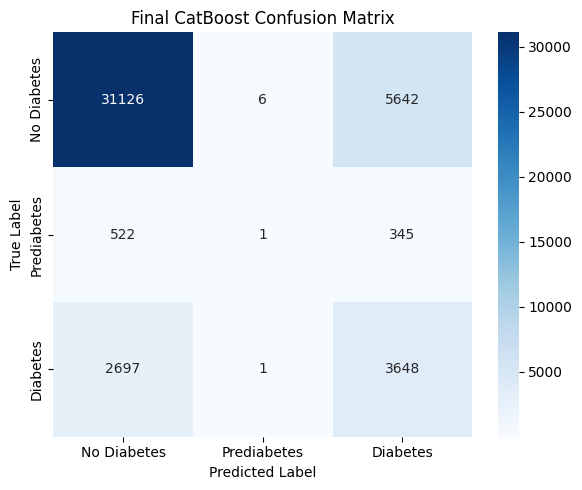

In [31]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("Final CatBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("catboost_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# CatBoost Explainability and Interpretability

After selecting the final class-weighted CatBoost model, explainability methods are applied to understand how the model makes predictions.

The methods used are:

- **Feature Importance:** global model interpretation
- **SHAP:** detailed global and local feature contribution
- **LIME:** local explanation for one selected patient/sample


## 12. Feature Importance for the Final CatBoost Model

- Feature importance shows which variables the final CatBoost model depends on the most.
- This is a global explanation because it summarizes the model behavior across the dataset.
- The graph is saved for the report as `catboost_feature_importance.png`.


         Feature  Importance
1        GenHlth   13.187164
0        BMI_Age   12.175145
3            BMI   10.756893
9         Income   10.355334
8       PhysHlth    8.943991
10     Education    8.332203
6            Age    7.314228
2         HighBP    6.956473
4       HighChol    6.833117
12  PhysActivity    4.230555


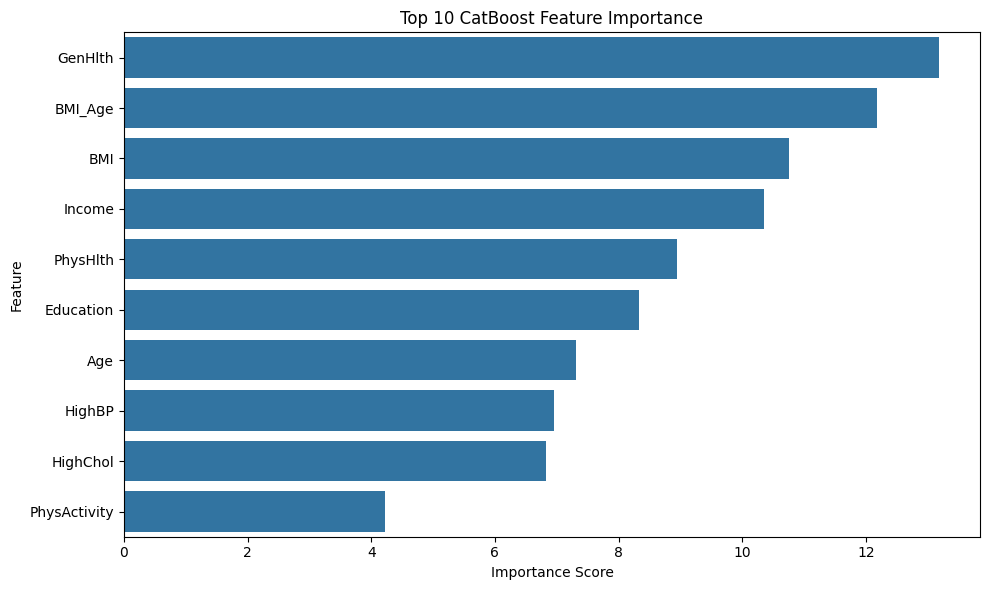

In [32]:
feature_names = X_train.columns if hasattr(X_train, "columns") else X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": catboost_final.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


### Feature Importance Interpretation

- The most important features should be checked to see whether they are medically meaningful.
- Features such as general health, BMI, age, blood pressure, cholesterol, and physical health are expected to be important for diabetes risk.
- This supports the interpretability of the model because the model relies on reasonable health-related variables.


## 13. SHAP Explanation for the Final CatBoost Model

- SHAP explains how features contribute to CatBoost predictions.
- It is stronger than normal feature importance because it shows contribution direction and magnitude.
- A sample of the test set is used to keep the notebook faster.
- The graph is saved for the report as `catboost_shap_summary.png`.


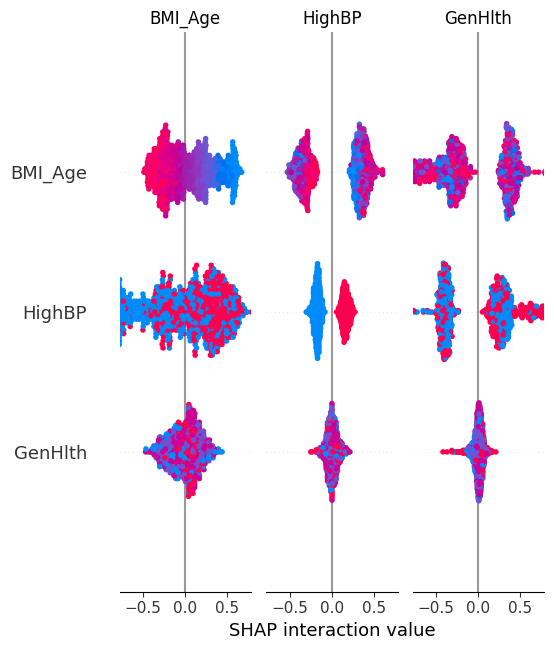

In [33]:
import shap

X_test_sample = X_test.sample(1000, random_state=42) if len(X_test) > 1000 else X_test.copy()

shap_explainer = shap.TreeExplainer(catboost_final)
shap_values = shap_explainer.shap_values(X_test_sample)

shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.tight_layout()
plt.savefig("catboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()


### SHAP Interpretation

- SHAP confirms whether the final CatBoost model uses meaningful features.
- Important health indicators should have strong SHAP impact.
- SHAP is useful because it explains both global feature importance and how feature values push predictions toward different diabetes classes.


## 14. LIME Explanation for One Test Sample

- LIME explains one individual prediction from the final CatBoost model.
- This is a local explanation, meaning it focuses on one patient/sample.
- The LIME table shows which features supported or opposed the selected prediction.
- The graph is saved for the report as `catboost_lime_explanation.png`.


In [34]:
from lime.lime_tabular import LimeTabularExplainer

class_names = ["No Diabetes", "Prediabetes", "Diabetes"]

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(feature_names),
    class_names=class_names,
    mode="classification"
)

sample_index = 0
sample_row = X_test.iloc[sample_index].values

lime_exp = lime_explainer.explain_instance(
    data_row=sample_row,
    predict_fn=catboost_final.predict_proba,
    num_features=10
)

predicted_class = int(catboost_final.predict(X_test.iloc[[sample_index]]).flatten()[0])
predicted_probabilities = catboost_final.predict_proba(X_test.iloc[[sample_index]])[0]

print("Selected sample index:", sample_index)
print("True class:", y_test.iloc[sample_index] if hasattr(y_test, "iloc") else y_test[sample_index])
print("Predicted class:", predicted_class)
print("Predicted probabilities:")

for class_name, probability in zip(class_names, predicted_probabilities):
    print(class_name + ":", probability)

lime_table = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature condition", "Contribution"]
)

lime_table


Selected sample index: 0
True class: 2.0
Predicted class: 2
Predicted probabilities:
No Diabetes: 0.2578186483378999
Prediabetes: 0.13011403018952764
Diabetes: 0.6120673214725724


,Feature condition,Contribution
0,0.00 < HighChol <= 1.00,0.029424
1,Education <= -0.50,0.013077
2,0.00 < HighBP <= 1.00,0.012975
3,GenHlth > 1.00,0.010070
4,0.00 < BMI_Age <= 0.46,0.007447
5,HeartDiseaseorAttack <= 0.00,0.006701
6,-0.50 < Age <= 0.00,-0.004503
7,Stroke <= 0.00,0.004122
8,PhysHlth > 1.00,0.003321
9,0.00 < BMI <= 0.57,0.002881


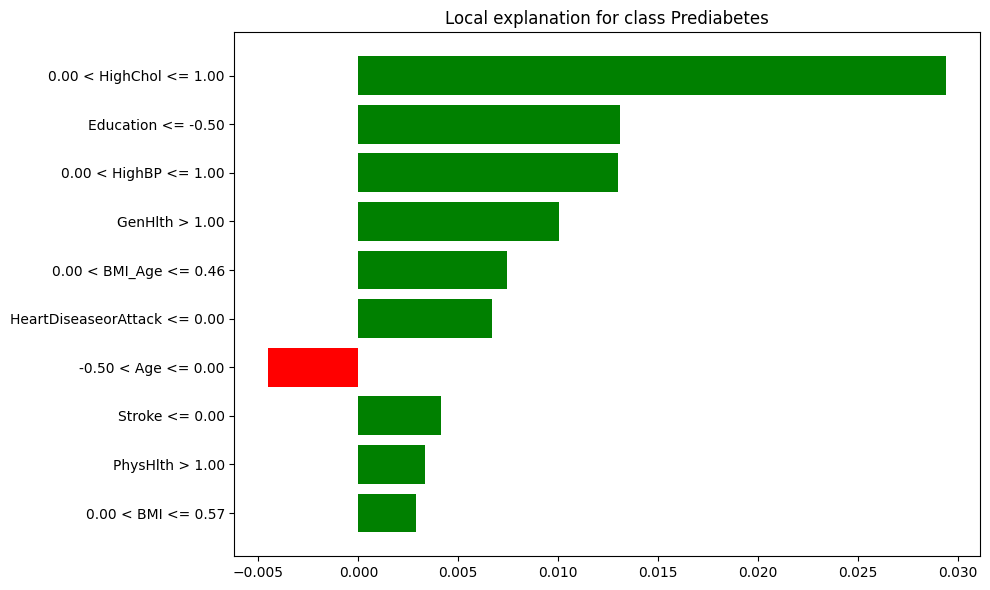

In [35]:
lime_fig = lime_exp.as_pyplot_figure()
lime_fig.set_size_inches(10, 6)
plt.tight_layout()
plt.savefig("catboost_lime_explanation.png", dpi=300, bbox_inches="tight")
plt.show()

lime_exp.show_in_notebook(show_table=True)


                 Feature  Importance
1                GenHlth    0.025241
0                BMI_Age    0.013041
3                    BMI    0.011482
2                 HighBP    0.010339
4               HighChol    0.006412
13     HvyAlcoholConsump    0.002511
9                 Income    0.002169
7   HeartDiseaseorAttack    0.002036
8               PhysHlth    0.001905
6                    Age    0.001889


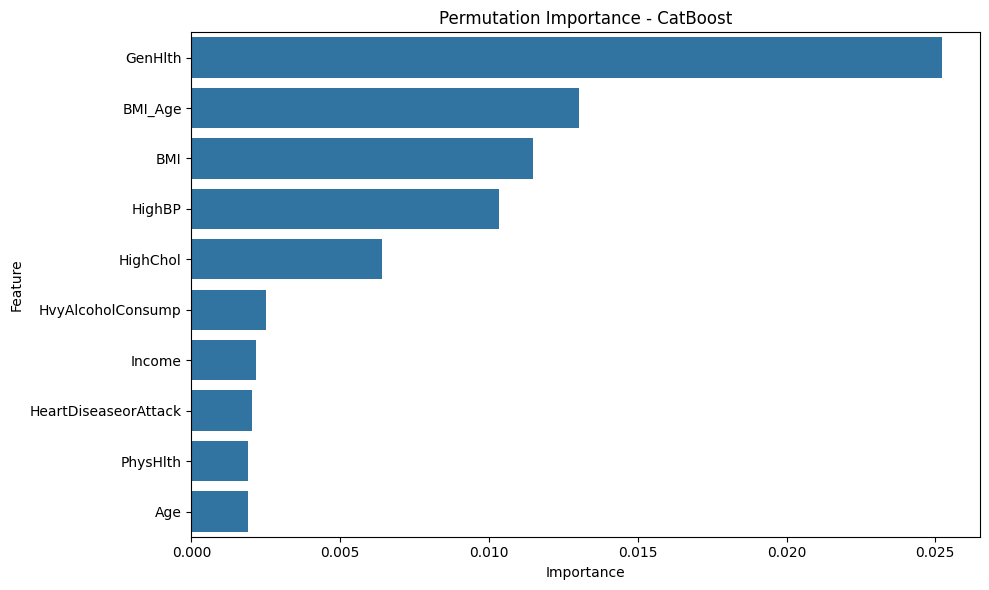

In [36]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permutation Importance
perm_importance = permutation_importance(
    catboost_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

# DataFrame
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(by="Importance", ascending=False)

print(perm_df.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=perm_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance - CatBoost")
plt.tight_layout()
plt.show()

### LIME Interpretation

- LIME explains why the final model made one specific prediction.
- Positive feature contributions support the predicted class, while negative contributions push against it.
- This is useful in healthcare because it provides a patient-level explanation instead of only a general model summary.


## 15. Final CatBoost Conclusion

- CatBoost without SMOTE produced the highest accuracy, but it was biased toward Class 0.
- CatBoost with SMOTE improved diabetes-class detection, especially Class 2 recall.
- Borderline-SMOTE with class weights was tested as a stronger imbalance-handling experiment.
- The final class-weighted CatBoost model was selected as the best balanced model because it improved diabetes detection while keeping acceptable overall performance.
- Feature importance, SHAP, and LIME showed that the model decisions can be interpreted using meaningful health-related features.


## CatBoost Notebook Summary

This notebook contains only the CatBoost experiments after the shared preprocessing pipeline. The final class-weighted CatBoost model is kept as the selected CatBoost variant because it provides a better balance between overall performance and diabetes-class detection than accuracy-only alternatives.